In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Load pre-trained EfficientNetB0 without the classification head
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze convolutional base

In [3]:
# Convert to tf.keras model for feature extraction
feature_extractor = tf.keras.Model(inputs=base_model.input, 
                                   outputs=tf.keras.layers.GlobalAveragePooling2D()(base_model.output))

In [4]:
# Load dataset using tf.data
train_data = image_dataset_from_directory("/Users/aswinikumar/Documents/major project/2/archive-2/Train_Alphabet", 
                                          image_size=(224, 224), batch_size=32)
test_data = image_dataset_from_directory("/Users/aswinikumar/Documents/major project/2/archive-2/Test_Alphabet", 
                                         image_size=(224, 224), batch_size=32)

Found 24300 files belonging to 27 classes.
Found 2700 files belonging to 27 classes.


In [5]:
print(len(test_data) * 32)  # Expected total number of images

2720


In [6]:
# Optional: Improve performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_data_1 = train_data.prefetch(buffer_size=AUTOTUNE)
test_data_1 = test_data.prefetch(buffer_size=AUTOTUNE)

In [7]:
# Function to extract features
def extract_features(dataset, model):
    features, labels = [], []
    for batch_images, batch_labels in dataset:
        batch_features = model.predict(batch_images)
        features.append(batch_features)
        labels.append(batch_labels.numpy())
    return np.vstack(features), np.hstack(labels)

In [8]:
# Extract features using EfficientNetB0
X_train, y_train = extract_features(train_data_1, feature_extractor)
X_test, y_test = extract_features(test_data_1, feature_extractor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

2025-04-24 15:19:17.558482: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

2025-04-24 15:19:48.018785: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
# Save features to disk
np.savez("/Users/aswinikumar/Documents/major project/2/archive-2/features_train.npz", X=X_train, y=y_train)
np.savez("/Users/aswinikumar/Documents/major project/2/archive-2/features_test.npz", X=X_test, y=y_test)

In [10]:
# Load saved features
train_data_z = np.load("/Users/aswinikumar/Documents/major project/2/archive-2/features_train.npz")
X_train, y_train = train_data_z['X'], train_data_z['y']

test_data_z = np.load("/Users/aswinikumar/Documents/major project/2/archive-2/features_test.npz")
X_test, y_test = test_data_z['X'], test_data_z['y']


In [11]:
print(test_data_z.files)  # Shows all keys in the .npz file


['X', 'y']


In [12]:
# import numpy as np

# Count class distribution before transformation
original_counts = np.zeros(48)  # Replace num_classes with the actual number of classes
for _, label in test_data:  # test_data before feature transformation
    for l in label.numpy():
        original_counts[l] += 1
print("Original class distribution:", original_counts)

# Count class distribution after transformation
transformed_counts = np.zeros(48)
for label in y_test:  # test_data after transformation
    transformed_counts[label] += 1
print("Transformed class distribution:", transformed_counts)


Original class distribution: [100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.]
Transformed class distribution: [100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.]


In [13]:
print(y_test.shape)
print(X_test.shape)

(2700,)
(2700, 1280)


In [14]:
print("Feature shape:", test_data_z["X"].shape)  # Features
print("Label shape:", test_data_z["y"].shape)    # Labels
print(y_test)

Feature shape: (2700, 1280)
Label shape: (2700,)
[ 7 16 15 ...  0 18  9]


In [15]:
print("Train feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)


Train feature shape: (24300, 1280)
Test feature shape: (2700, 1280)


In [16]:
# Initialize scaler
scaler = StandardScaler()


In [17]:

# Scale training features before fitting SVM
X_train_scaled = scaler.fit_transform(X_train)  

X_test_scaled = scaler.transform(X_test)


In [18]:
print(X_test_scaled.shape)

(2700, 1280)


In [19]:
import joblib

In [20]:
# 2️⃣ Train SGD SVM Model
from tqdm import tqdm
# from sklearn.linear_model import SGDClassifier
import pickle



# Initialize SVC with RBF kernel
svc_rbf_eff = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42,decision_function_shape='ovr')

# Manually fit the model with tqdm
for epoch in tqdm(range(1), desc="Training SVM"):
    svc_rbf_eff.fit(X_train_scaled, y_train)

# Lists to store accuracy for plotting
history = {'train_acc': [], 'val_acc': []}

# print(f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")

# Save the training history
with open('svc_rbf_training_history.pkl', 'wb') as f:
    pickle.dump(history, f)



# Save the trained model
joblib.dump(svc_rbf_eff, "svc_rbf_efficeint.pkl")

Training SVM: 100%|██████████████████████████████| 1/1 [02:24<00:00, 144.83s/it]


['svc_rbf_efficeint.pkl']

In [21]:
# Load the model later
svc_rbf_eff = joblib.load("svc_rbf_efficeint.pkl")

In [22]:
# Evaluate on validation and test sets
y_test_pred = svc_rbf_eff.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_test_pred) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.67%


In [23]:
from sklearn.metrics import classification_report


# Classification report
print("Classification Report on Test Data:")
print(classification_report(y_test, y_test_pred, digits=4))

Classification Report on Test Data:
              precision    recall  f1-score   support

           0     0.8288    0.9200    0.8720       100
           1     0.9895    0.9400    0.9641       100
           2     0.8696    1.0000    0.9302       100
           3     0.9684    0.9200    0.9436       100
           4     0.8687    0.8600    0.8643       100
           5     0.8889    0.8800    0.8844       100
           6     0.9200    0.9200    0.9200       100
           7     0.8257    0.9000    0.8612       100
           8     0.9697    0.9600    0.9648       100
           9     0.8947    0.8500    0.8718       100
          10     0.9082    0.8900    0.8990       100
          11     0.9222    0.8300    0.8737       100
          12     0.8725    0.8900    0.8812       100
          13     0.8137    0.8300    0.8218       100
          14     0.8384    0.8300    0.8342       100
          15     0.9451    0.8600    0.9005       100
          16     0.8716    0.9500    0.9091  

In [24]:
unique_labels = test_data.class_names
print(unique_labels)

['A', 'B', 'Blank', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


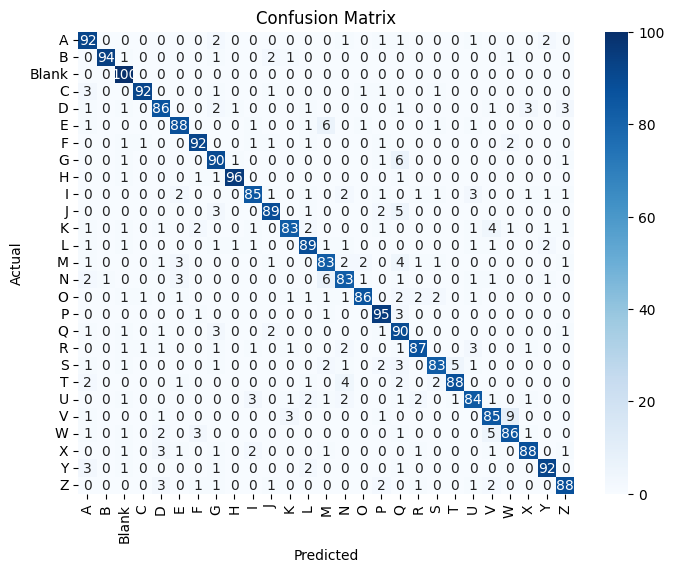

<Axes: >

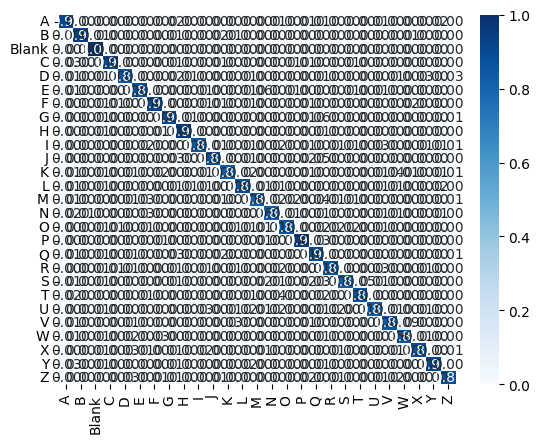

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)  # Ensure y_test and y_pred are defined

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)

In [27]:
# Compute confusion matrix
# cm = confusion_matrix(y_test, y_test_pred)

# # Print TP, TN, FP, FN for each class
# num_classes = cm.shape[0]

metrics = {}

for i in range(27):
    tp = cm[i, i]  # True Positives for class i
    fn = np.sum(cm[i, :]) - tp  # False Negatives: actual class i but predicted as others
    fp = np.sum(cm[:, i]) - tp  # False Positives: predicted as class i but actually others
    tn = np.sum(cm) - (tp + fp + fn)  # True Negatives: all others

    metrics[f"Class {i}"] = {"TP": tp, "TN": tn, "FP": fp, "FN": fn}

# Print the results
for class_labels, values in metrics.items():
    print(f"{class_labels}: TP={values['TP']}, TN={values['TN']}, FP={values['FP']}, FN={values['FN']}")

Class 0: TP=92, TN=2581, FP=19, FN=8
Class 1: TP=94, TN=2599, FP=1, FN=6
Class 2: TP=100, TN=2585, FP=15, FN=0
Class 3: TP=92, TN=2597, FP=3, FN=8
Class 4: TP=86, TN=2587, FP=13, FN=14
Class 5: TP=88, TN=2589, FP=11, FN=12
Class 6: TP=92, TN=2592, FP=8, FN=8
Class 7: TP=90, TN=2581, FP=19, FN=10
Class 8: TP=96, TN=2597, FP=3, FN=4
Class 9: TP=85, TN=2590, FP=10, FN=15
Class 10: TP=89, TN=2591, FP=9, FN=11
Class 11: TP=83, TN=2593, FP=7, FN=17
Class 12: TP=89, TN=2587, FP=13, FN=11
Class 13: TP=83, TN=2581, FP=19, FN=17
Class 14: TP=83, TN=2584, FP=16, FN=17
Class 15: TP=86, TN=2595, FP=5, FN=14
Class 16: TP=95, TN=2586, FP=14, FN=5
Class 17: TP=90, TN=2567, FP=33, FN=10
Class 18: TP=87, TN=2592, FP=8, FN=13
Class 19: TP=83, TN=2592, FP=8, FN=17
Class 20: TP=88, TN=2594, FP=6, FN=12
Class 21: TP=84, TN=2586, FP=14, FN=16
Class 22: TP=85, TN=2584, FP=16, FN=15
Class 23: TP=86, TN=2587, FP=13, FN=14
Class 24: TP=88, TN=2593, FP=7, FN=12
Class 25: TP=92, TN=2593, FP=7, FN=8
Class 26: TP=88

In [28]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet  import preprocess_input

# Ensure sgd_svm is already trained in your script before calling this function

def predict_image(image_path, feature_extractor, model,scaler):
    # Load and preprocess the image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    # img_array /= 255.0  # Normalize
    img_array = preprocess_input(img_array)  


    # Extract features using ResNet50
    features = feature_extractor.predict(img_array)
    features = np.array(features).reshape(1, -1)
    print(features.shape)

     # Scale test features before prediction
    features_scaled = scaler.transform(features)  # Individual image feature
    predicted_class = model.predict(features_scaled)
    print("Decision function output:", model.decision_function(features_scaled))

    # Show image and prediction
    plt.imshow(np.array(img).astype('uint8'))
    plt.axis('off')
    
    # Optional: map numeric label to class name
    if unique_labels:
        label = unique_labels[predicted_class[0]]
    else:
        label = predicted_class[0]
        
    plt.title(f"Predicted class: {label}")
    plt.show()

    return label

# Provide your image path
image_path = r"D:\Sample_Run\image\bg_removed_splitted\test\15\28.png"

# Ensure `sgd_svm` and `feature_extractor` are defined and trained before calling this function
predicted_class = predict_image(image_path, feature_extractor, svc_rbf_eff,scaler)
print(f"Predicted class: {predicted_class}")


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Sample_Run\\image\\bg_removed_splitted\\test\\15\\28.png'